In [17]:
import numpy as np
import matplotlib.pyplot as plt
import utils
import math

import sys

if 'google.colab' in sys.modules:
    !pip install -q numpy matplotlib scipy scikit-learn

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Section A: Empirical data visualisation


In this section, we will use empirical head direction data recorded in the Anterodorsal Nucleus of the thalamus (ADN) from Duszkiewicz et al., 2024, *Nature Neuroscience*.  
You can find the paper [Here](https://www.nature.com/articles/s41593-024-01588-5), and the raw dataset [Here](https://figshare.com/articles/dataset/Local_origin_of_excitatory-inhibitory_tuning_equivalence_in_a_cortical_network_Duszkiewicz_et_al_2024_/24921252).

<img src="/Users/zilong/Desktop/HeaddirectionCoding/Figures/recordingsite.png" alt="Recording site" width="400">

### A.1 Load the empirical data and perform a raster plot


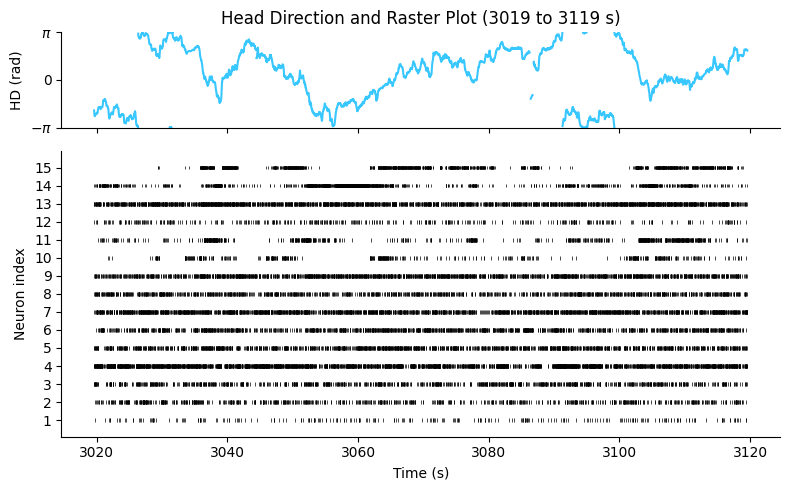

In [2]:
#load processed data
loaded = np.load('NeuralData/EmpiricalHDData.npz')

t = loaded['t']
angle_data = loaded['angle_data']
spike_array = loaded['spike_array']


#------------------------------------------------------
fig, (ax1, ax2) = utils.plot_hd_raster_with_trace(
    t,
    angle_data,
    spike_array,
    t_start=t[0],
    window_duration=100,
)

### A.2 Plot the direction tuning map of some cells

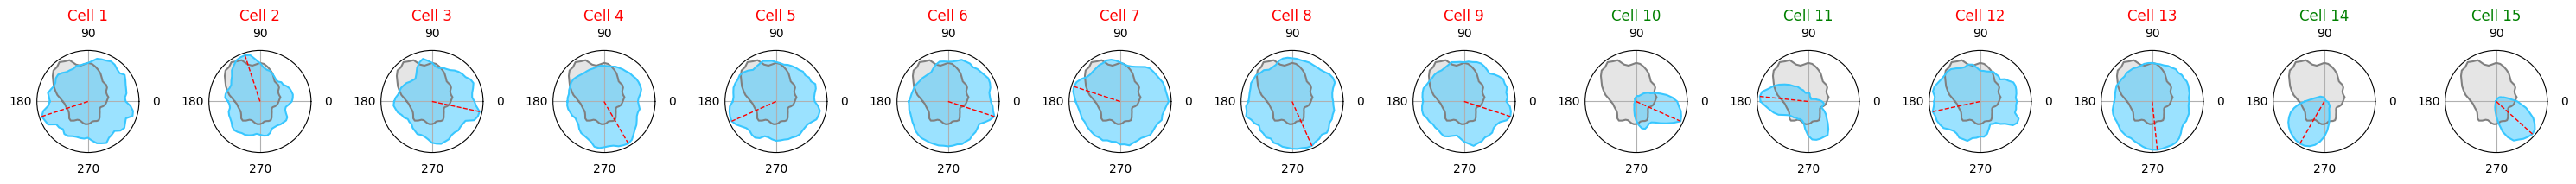

In [3]:
hd_label = loaded['hd_label']
n_cells = spike_array.shape[0]

fig = plt.figure(figsize=(2 * n_cells, 2), dpi=100)

for i in range(n_cells):
    ax = fig.add_subplot(1, n_cells, i + 1, polar=True)

    fig, ax = utils.plot_head_direction_tuning(
        t,
        angle_data,
        spike_array[i],
        ax=ax
    )

    ax.set_title(
        f'Cell {i + 1}',
        color='green' if hd_label[i] == 1 else 'red'
    )

plt.tight_layout()
plt.show()

### A.3 Visualise the population activity of all head direction cells in a recoding session

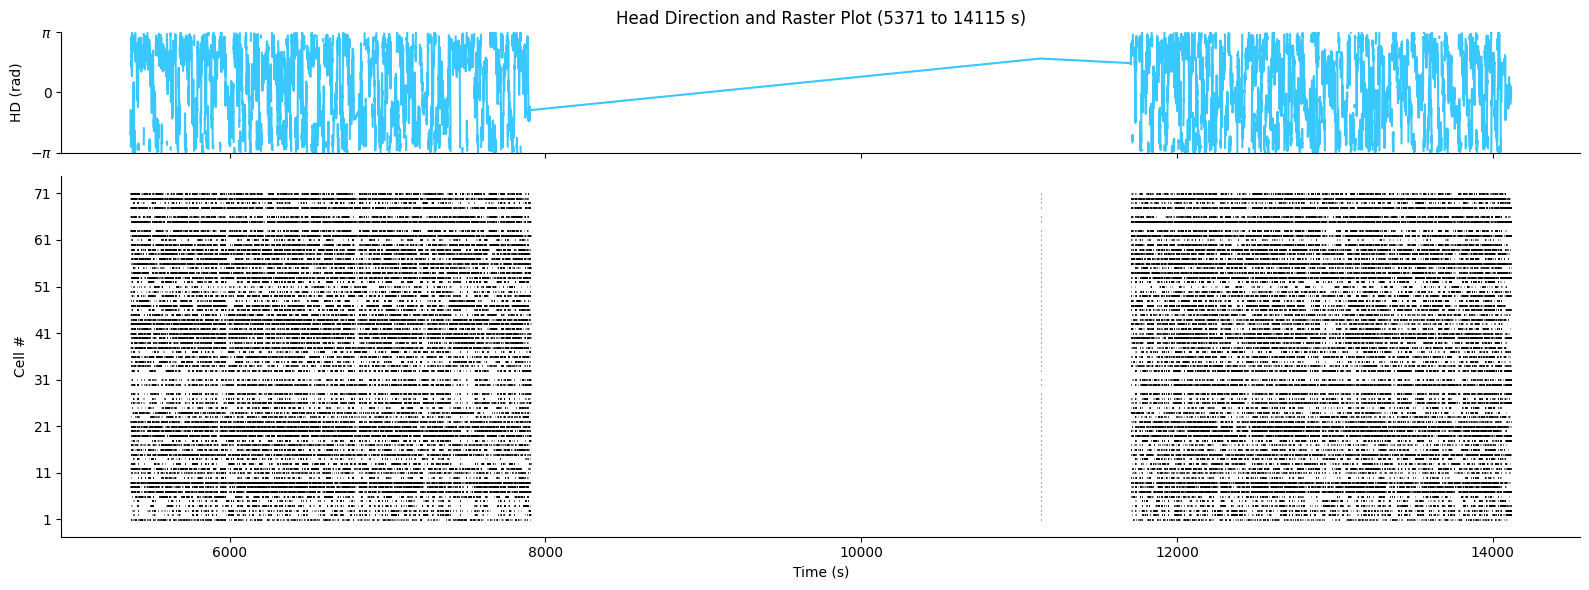

In [4]:
loaded = np.load(
    'NeuralData/HDC_binned_Dataset_1_A3701-191119.npz',
    allow_pickle=True
)

t_binned = loaded['t_binned']
angle_binned = loaded['angle_binned']
spike_binned = loaded['spike_binned']

fig, (ax1, ax2) = utils.plot_hd_raster_with_trace(
    t_binned,
    angle_binned,
    spike_binned,
    t_start=t_binned[0],
    window_duration=t_binned[-1] - t_binned[0],
    figsize=(16, 6),
)

n_cells = spike_binned.shape[0]
tick_step = 10
tick_positions = np.arange(1, n_cells + 1, tick_step)

ax2.set_yticks(tick_positions)
ax2.set_yticklabels(tick_positions)
ax2.set_ylabel('Cell #')

plt.show()

### Visualise the directional tuning map of these cells

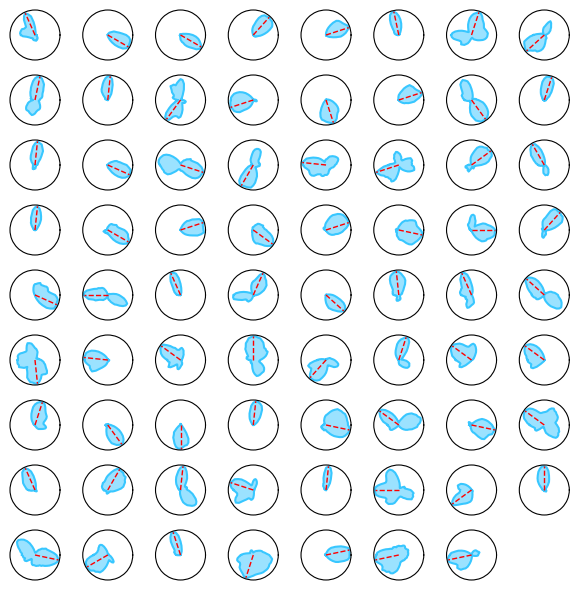

In [5]:
n_cells = spike_binned.shape[0]
n_cols = 8
n_rows = math.ceil(n_cells / n_cols)

fig = plt.figure(figsize=(6,6), dpi=100)

for i in range(n_cells):
    ax = fig.add_subplot(n_rows, n_cols, i + 1, polar=True)

    _, ax = utils.plot_head_direction_tuning(
        t_binned,
        angle_binned,
        spike_binned[i],
        ax=ax
    )

    # Remove the grey occupancy curve and fill
    lines = ax.lines
    if len(lines) >= 1:
        lines[0].set_visible(False)  # grey line
    if len(ax.collections) >= 1:
        ax.collections[0].set_visible(False)  # grey fill

    # Remove all ticks and labels
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

### Let's a dimensional reduction of the population vectors

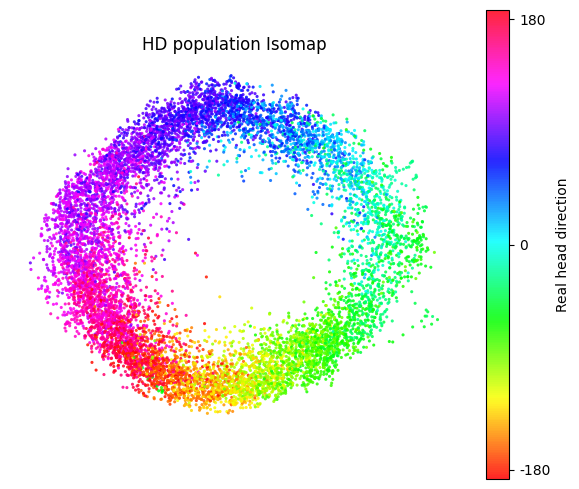

In [6]:
results = utils.plot_hd_isomap(
    t_binned,
    angle_binned,
    spike_binned,
    smooth_sd=0.4,
    n_neighbors=12,
    max_points=10000,
    figsize=(6, 5),
)
plt.show()

# Section B: Computational Modelling of a Ring Attractor Model for the Head Direction Cell Network



### B.1 Model parameters

In [7]:
from dataclasses import dataclass


def wrap_angle(angle):
    """Wrap angle to the interval [-pi, pi)."""
    return (angle + np.pi) % (2 * np.pi) - np.pi


def circular_distance(theta_a, theta_b):
    """Shortest signed distance between two angles."""
    return wrap_angle(theta_a - theta_b)



@dataclass
class RingAttractorConfig:
    n_neurons: int = 128
    dt: float = 0.02
    tau: float = 0.12

    total_time: float = 12.0

    excitation_strength: float = 1.1
    inhibition_strength: float = 0.8
    excitation_width: float = 0.8
    inhibition_width: float = 1.2

    tonic_drive: float = 0.08
    noise_std: float = 0.0

    bump_width: float = 0.35
    bump_height: float = 1.0

    norm_strength: float = 0.08

    # New parameters for conjunctive AV-by-HD inputs
    velocity_gain: float = 1.5
    asymmetry_shift: float = 2 * np.pi / 128 * 3
    conjunctive_width: float = 0.45




### B2. Build recurrent connectivity: Nearby neurons excite each other. Neurons further away contribute more inhibition. This is the core ingredient of a ring attractor.



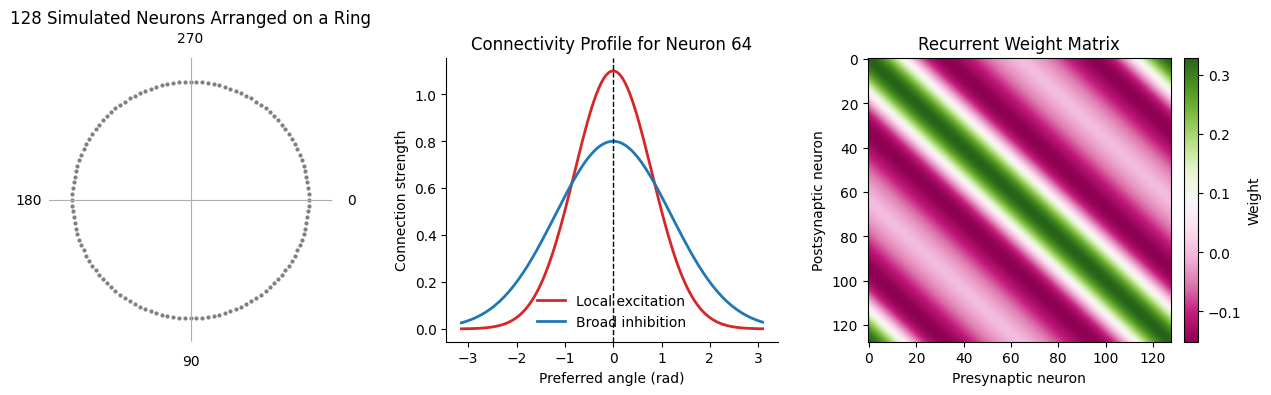

In [8]:
config = RingAttractorConfig()

preferred_angles = np.linspace(-np.pi, np.pi, config.n_neurons, endpoint=False)
angle_diffs = circular_distance(preferred_angles[:, None], preferred_angles[None, :])

local_excitation = config.excitation_strength * np.exp(
    -(angle_diffs ** 2) / (2 * config.excitation_width ** 2)
)

broad_inhibition = config.inhibition_strength * np.exp(
    -(angle_diffs ** 2) / (2 * config.inhibition_width ** 2)
)

weights = local_excitation - broad_inhibition
weights -= np.mean(weights, axis=1, keepdims=True)

fig, (ax1, ax2, ax3) = utils.plot_ring_connectivity_layout(
    preferred_angles,
    weights,
    local_excitation=local_excitation,
    broad_inhibition=broad_inhibition,
    neuron_idx=64,
    weight_cmap='PiYG',
    figsize=(13, 4),
)
plt.show()

### B.3. Define the single-layer ring attractor dynamics

Now we define how the network evolves over time.

- `firing_rate(...)` converts internal activity into neural firing rates.
- `initial_bump(...)` creates a localized packet of activity on the ring.
- `step_static(...)` updates the network using only symmetric recurrent connectivity.
- `decode_angle(...)` reads out the represented head direction from the population.



In [9]:
def firing_rate(activity):
    activity_pos = np.maximum(activity, 0.0)
    rate_num = activity_pos ** 2
    rate_den = 1.0 + config.norm_strength * np.sum(rate_num)
    return rate_num / rate_den


def initial_bump(center_angle=0.0):
    diffs = circular_distance(preferred_angles, center_angle)
    return config.bump_height * np.exp(
        -(diffs ** 2) / (2 * config.bump_width ** 2)
    )


def step_static(activity, rng):
    rates = firing_rate(activity)
    recurrent_drive = weights @ rates
    noise = rng.normal(0.0, config.noise_std, size=activity.shape)

    total_drive = recurrent_drive + config.tonic_drive + noise
    delta = config.dt * (-activity + total_drive) / config.tau
    return activity + delta


def decode_angle(rates):
    vector = np.sum(rates * np.exp(1j * preferred_angles))
    return np.angle(vector)

<div style="font-size:28px; font-weight:700; color:#c65d00;">
Q1: Think about the following question: can symmetric recurrent connectivity alone maintain a stable bump?
</div>

### B4. Run a simulation: pin the network activity at t = 0 and watch how it evolves over time

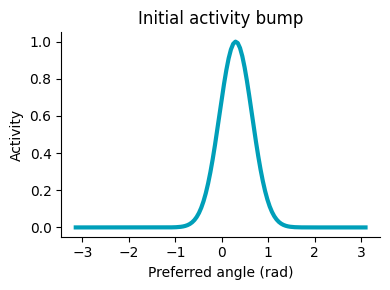

In [10]:
activity0 = initial_bump(center_angle=0.3)

fig, ax = plt.subplots(figsize=(4, 3), dpi=100)
ax.plot(preferred_angles, activity0, linewidth=3, color='#009FB9')
ax.set_xlabel('Preferred angle (rad)')
ax.set_ylabel('Activity')
ax.set_title('Initial activity bump')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

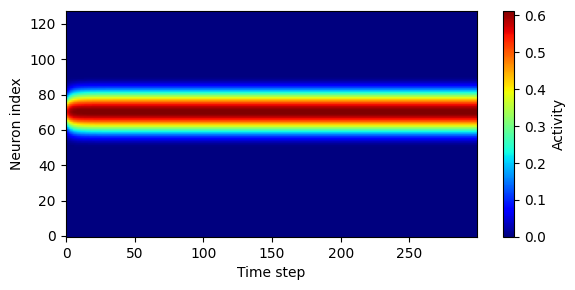

In [11]:
rng = np.random.default_rng(7)
n_steps = 300

activity = initial_bump(center_angle=0.3)
activity_history = np.zeros((n_steps, config.n_neurons))
decoded = np.zeros(n_steps)

for t in range(n_steps):
    activity = step_static(activity, rng=rng)
    rates = firing_rate(activity)
    activity_history[t] = rates
    decoded[t] = decode_angle(rates)

fig, ax = plt.subplots(figsize=(6, 3), dpi=100)
im = ax.imshow(
    activity_history.T,
    aspect='auto',
    origin='lower',
    cmap='jet',
    vmin=np.percentile(activity_history, 1),
    vmax=np.percentile(activity_history, 99),
)
ax.set_xlabel('Time step')
ax.set_ylabel('Neuron index')
fig.colorbar(im, ax=ax, label='Activity')
plt.tight_layout()
plt.show()

# Section C. Computational Modelling of a Velocity Integrator for the Head direction network

The symmetric recurrent ring can hold a bump in place.  
To make the bump move, we now add two conjunctive AV-by-HD input populations.  
One is shifted clockwise and the other is shifted anticlockwise.  

The model schematic below is adapted from [Skaggs et al., 1994, NeurIPS](https://proceedings.neurips.cc/paper/1994/file/024d7f84fff11dd7e8d9c510137a2381-Paper.pdf).

<p align="center">
  <img src="Figures/SkaggsModel.png" alt="Skaggs model schematic" width="500">
</p>

### C.1. Define the core network functions

We first write the generic helper functions.
At this stage, the single-layer recurrent network is enough to hold a bump.
Later we will add asymmetric angular-velocity inputs on top of this base model.

In [12]:
def firing_rate(activity):
    activity_pos = np.maximum(activity, 0.0)
    rate_num = activity_pos ** 2
    rate_den = 1.0 + config.norm_strength * np.sum(rate_num)
    return rate_num / rate_den

def initial_bump(center_angle=0.0):
    diffs = circular_distance(preferred_angles, center_angle)
    return config.bump_height * np.exp(
        -(diffs ** 2) / (2 * config.bump_width ** 2)
    )

def make_shifted_kernel(shift, preferred_angles):
    shifted_diffs = circular_distance(
        preferred_angles[:, None],
        preferred_angles[None, :] + shift
    )
    kernel = np.exp(-(shifted_diffs ** 2) / (2 * config.conjunctive_width ** 2))
    kernel /= kernel.sum(axis=1, keepdims=True)
    return kernel


def conjunctive_inputs(rates, angular_velocity, W_cw, W_ccw):
    cw_amp = max(angular_velocity, 0.0)
    ccw_amp = max(-angular_velocity, 0.0)

    cw_population = cw_amp * rates
    ccw_population = ccw_amp * rates

    input_cw = config.velocity_gain * (W_cw @ cw_population)
    input_ccw = config.velocity_gain * (W_ccw @ ccw_population)

    return input_cw, input_ccw


def step_with_av(activity, angular_velocity, rng, W_cw, W_ccw):
    rates = firing_rate(activity)

    recurrent_drive = weights @ rates
    input_cw, input_ccw = conjunctive_inputs(
        rates,
        angular_velocity,
        W_cw,
        W_ccw,
    )
    noise = rng.normal(0.0, config.noise_std, size=activity.shape)

    total_drive = (
        recurrent_drive
        + input_cw
        + input_ccw
        + config.tonic_drive
        + noise
    )

    delta = config.dt * (-activity + total_drive) / config.tau
    return activity + delta


def decode_angle(rates):
    vector = np.sum(rates * np.exp(1j * preferred_angles))
    return np.angle(vector)

### C.2 Set symmetric recurrent connections in the ring attractor and asymmetric connections from angular velocity cells to head direction cells

In [13]:
config = RingAttractorConfig()

preferred_angles = np.linspace(-np.pi, np.pi, config.n_neurons, endpoint=False)

preferred_angles = np.linspace(-np.pi, np.pi, config.n_neurons, endpoint=False)
angle_diffs = circular_distance(preferred_angles[:, None], preferred_angles[None, :])

local_excitation = config.excitation_strength * np.exp(
    -(angle_diffs ** 2) / (2 * config.excitation_width ** 2)
)

broad_inhibition = config.inhibition_strength * np.exp(
    -(angle_diffs ** 2) / (2 * config.inhibition_width ** 2)
)

weights = local_excitation - broad_inhibition
weights -= np.mean(weights, axis=1, keepdims=True)

W_cw = make_shifted_kernel(+config.asymmetry_shift, preferred_angles)
W_ccw = make_shifted_kernel(-config.asymmetry_shift, preferred_angles)


### Let's visualise the weights

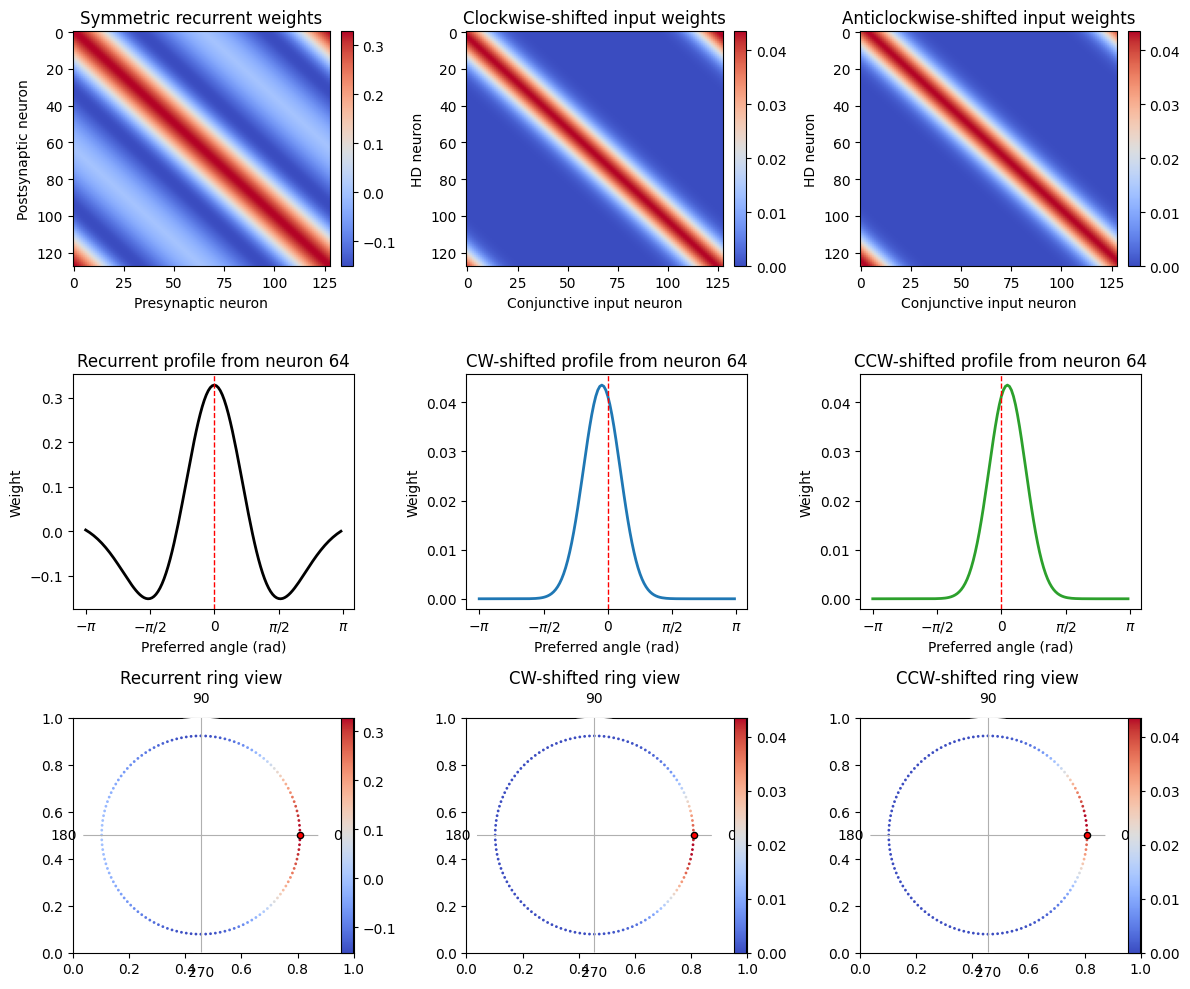

In [14]:

neuron_idx = 64

fig = plt.figure(figsize=(12, 10), dpi=100)
axes = fig.subplots(3, 3)

# --------------------------------------------------
# Top row: full connectivity matrices
# --------------------------------------------------
im0 = axes[0, 0].imshow(weights, aspect='auto', cmap='coolwarm')
axes[0, 0].set_title('Symmetric recurrent weights')
axes[0, 0].set_xlabel('Presynaptic neuron')
axes[0, 0].set_ylabel('Postsynaptic neuron')
fig.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)

im1 = axes[0, 1].imshow(W_cw, aspect='auto', cmap='coolwarm')
axes[0, 1].set_title('Clockwise-shifted input weights')
axes[0, 1].set_xlabel('Conjunctive input neuron')
axes[0, 1].set_ylabel('HD neuron')
fig.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

im2 = axes[0, 2].imshow(W_ccw, aspect='auto', cmap='coolwarm')
axes[0, 2].set_title('Anticlockwise-shifted input weights')
axes[0, 2].set_xlabel('Conjunctive input neuron')
axes[0, 2].set_ylabel('HD neuron')
fig.colorbar(im2, ax=axes[0, 2], fraction=0.046, pad=0.04)

# --------------------------------------------------
# Middle row: one neuron's profile as a function of angle
# --------------------------------------------------
axes[1, 0].plot(preferred_angles, weights[neuron_idx], linewidth=2, color='black')
axes[1, 0].axvline(preferred_angles[neuron_idx], color='red', linestyle='--', linewidth=1)
axes[1, 0].set_title(f'Recurrent profile from neuron {neuron_idx}')
axes[1, 0].set_xlabel('Preferred angle (rad)')
axes[1, 0].set_ylabel('Weight')

axes[1, 1].plot(preferred_angles, W_cw[neuron_idx], linewidth=2, color='tab:blue')
axes[1, 1].axvline(preferred_angles[neuron_idx], color='red', linestyle='--', linewidth=1)
axes[1, 1].set_title(f'CW-shifted profile from neuron {neuron_idx}')
axes[1, 1].set_xlabel('Preferred angle (rad)')
axes[1, 1].set_ylabel('Weight')

axes[1, 2].plot(preferred_angles, W_ccw[neuron_idx], linewidth=2, color='tab:green')
axes[1, 2].axvline(preferred_angles[neuron_idx], color='red', linestyle='--', linewidth=1)
axes[1, 2].set_title(f'CCW-shifted profile from neuron {neuron_idx}')
axes[1, 2].set_xlabel('Preferred angle (rad)')
axes[1, 2].set_ylabel('Weight')

for ax in axes[1]:
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_xticklabels([r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])

# --------------------------------------------------
# Bottom row: ring views of the same connectivity profiles
# --------------------------------------------------
ring_axes = [fig.add_subplot(3, 3, 7, polar=True), fig.add_subplot(3, 3, 8, polar=True), fig.add_subplot(3, 3, 9, polar=True)]
ring_weights = [weights[neuron_idx], W_cw[neuron_idx], W_ccw[neuron_idx]]
ring_titles = ['Recurrent ring view', 'CW-shifted ring view', 'CCW-shifted ring view']

for ax, w, title in zip(ring_axes, ring_weights, ring_titles):
    ax.set_theta_zero_location('E')
    ax.set_theta_direction(1)
    sc = ax.scatter(preferred_angles, np.full_like(preferred_angles, 1.35), c=w, s=4, cmap='coolwarm', edgecolors='none')
    ax.scatter(preferred_angles[neuron_idx], 1.35, s=20, color='red', edgecolors='black', linewidths=1.0, zorder=5)
    ax.set_title(title)
    ax.set_rticks([])
    ax.spines['polar'].set_visible(False)
    ax.set_ylim(0, 1.6)
    ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2])
    ax.set_xticklabels(['0', '90', '180', '270'])
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.08)

plt.tight_layout()
plt.show()


### Visulise in a different way

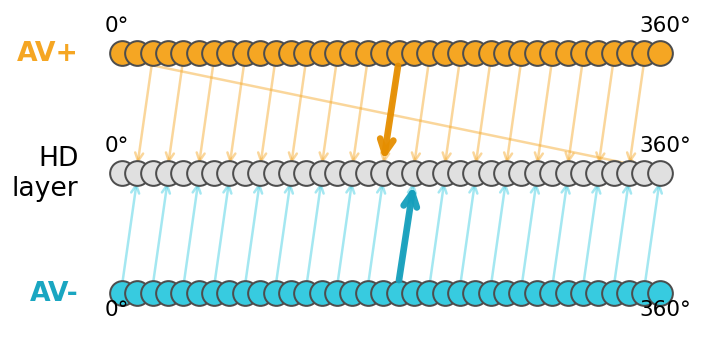

In [15]:
fig, ax = utils.plot_av_hd_schematic(
    W_cw=W_cw,
    W_ccw=W_ccw,
    n_neurons=36,
    step=2,
    figsize=(6, 3),
)
plt.show()


<div style="font-size:28px; font-weight:700; color:#c65d00;">
Q2: Think about the following question: how does angular velocity drive the activity bump to move around the ring?
</div>

### C.3 Let's do some simulation: drive the network with clockwise and anticlockwise angular velocity inputs

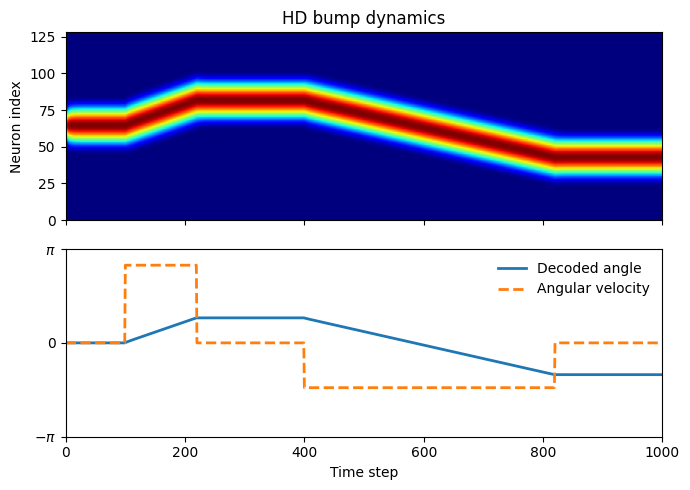

In [16]:
rng = np.random.default_rng(7)
n_steps = 1000

activity = initial_bump(center_angle=0.0)
activity_history = np.zeros((n_steps, config.n_neurons))
decoded = np.zeros(n_steps)

velocity_profile = np.zeros(n_steps)
velocity_profile[100:220] = 2.6
velocity_profile[400:820] = -1.5

for t in range(n_steps):
    activity = step_with_av(
        activity,
        angular_velocity=velocity_profile[t],
        rng=rng,
        W_cw=W_cw,
        W_ccw=W_ccw,
    )
    rates = firing_rate(activity)
    activity_history[t] = rates
    decoded[t] = decode_angle(rates)

fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True)

im = axes[0].imshow(
    activity_history.T,
    aspect='auto',
    origin='lower',
    cmap='jet',
    vmin=np.percentile(activity_history, 1),
    vmax=np.percentile(activity_history, 99),
    extent=[0, n_steps, 0, config.n_neurons],
)
axes[0].set_ylabel('Neuron index')
axes[0].set_title('HD bump dynamics')

axes[1].plot(decoded, linewidth=2, label='Decoded angle')
axes[1].plot(velocity_profile, linewidth=2, linestyle='--', label='Angular velocity')
axes[1].set_xlabel('Time step')
axes[1].set_ylim(-np.pi, np.pi)
axes[1].set_yticks([-np.pi, 0, np.pi])
axes[1].set_yticklabels([r'$-\pi$', '0', r'$\pi$'])
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

<div style="font-size:22px; font-weight:700; color:#c65d00;">
Mini project 1: do these cells show angular velocity tuning?
</div>

Try the following steps:

1. Compute angular velocity from the head direction trace.
2. Correct for circular wrap-around when angle crosses `-\pi` and `\pi`.
3. Divide angular velocity into bins, with `0` in the middle.
4. For each bin, find the corresponding time points.
5. For each cell, compute the mean firing rate in that bin.
6. Plot firing rate versus angular velocity.
7. Ask: which cells seem tuned to clockwise or anticlockwise turning?

See some examples here: [Muir and Taube, 2023, Journal of Neuroscience](https://www.jneurosci.org/content/43/49/8403).

<div style="font-size:22px; font-weight:700; color:#c65d00;">
Mini project 2: calibrate the velocity gain
</div>

The goal is to find a velocity gain such that integrating angular velocity produces an internal head direction estimate that matches the ground-truth head direction.

Try the following steps:

1. Use angular velocity as the input signal.
2. Use the head direction trace as the ground-truth output.
3. Start with an initial guess for `velocity_gain`.
4. Integrate angular velocity over time to generate a predicted internal direction.
5. Compare the predicted direction with the ground-truth direction.
6. Define an error metric.
   Hint: use circular error, not ordinary subtraction.
7. Adjust `velocity_gain` to reduce this error.
8. Ask: what value of `velocity_gain` gives the best match between the integrated estimate and the real head direction?
9. Ask: could you fit the gain value automatically?
   For example, could you use backpropagation, a delta rule, or another error-driven learning rule? 

<div style="font-size:22px; font-weight:700; color:#c65d00;">
Mini project 3: can the velocity integrator model generate a ring manifold like the real data?
</div>

Try the following steps:

1. Generate a continuous angular velocity input that changes over time.
2. Feed this angular velocity signal into the velocity integrator model.
3. Record the population activity of the ring attractor over time.
4. Treat the population activity at each time point as one population vector.
5. Apply dimensionality reduction to these population vectors.
   Hint: you can try Isomap, as in the empirical-data section.
6. Visualize the low-dimensional embedding.
7. Ask: does the model population activity lie on a ring-like manifold, similar to the empirical data?
8. Compare the simulated manifold with the real one.
   For example, compare its shape, smoothness, continuity, and how well angle is organized around the ring.